# Imports

In [1]:
import numpy as np
from torch.utils.data import Dataset,DataLoader
import pandas as pd
import pickle
import os
import gzip
import pytorch_lightning

/home/ethan2/local/conda/envs/my_conda_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
df_train = pd.read_pickle("/home/ethan2/GrowthCurve/data/train/df_well_train_Celine_clusters_mad_4.pkl")
df_val  = pd.read_pickle("/home/ethan2/GrowthCurve/data/validation/df_well_validation_Celine_clusters_mad_4.pkl") 


## Data Class from .py

In [10]:
from __future__ import annotations
import math, re
from dataclasses import dataclass
from typing import Any, Dict, Iterable, Optional, Tuple, List, Sequence
from typing import Literal
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.interpolate import RectBivariateSpline
from torch.utils.data._utils.collate import default_collate
import pickle

@dataclass(frozen=True)
class CompoundMeta:
    compound: str
    smiles: str
    pivot_od: pd.DataFrame            # index: Timepoint, columns: Concentration → OD
    pivot_cls: pd.DataFrame           # same axes → is_Active
    t_vals: np.ndarray                # sorted unique timepoints (float)
    c_vals: np.ndarray                # sorted unique concentrations (float)
    single_conc: bool                 # True if only one conc present
    t_min: float
    t_max: float
    logc_min: float
    logc_max: float
    is_active_at_12_50: bool  # NEW: if compound is active at time 12 and conc 50
    fps_by_family: Dict[str, np.ndarray]  # NEW: per-library fingerprint vectors
    


class PerCompoundDataset(Dataset):
    """
    Returns one item per compound containing k sampled (t,c) with:
      - y_reg: interpolated OD (regression target)
      - y_cls: interpolated classification target (placeholder for now)
      - features_by_family: dict {family: fingerprint tensor}

    If a compound has >1 concentration → local RectBivariateSpline in (time, log(conc)).
    If only one concentration → calls placeholder _interpolate_regression_single_conc().
    Classification interpolation is also a placeholder: _interpolate_classification().

    Output dict keys:
      {
        'compound', 'smiles', 'single_conc',
        't': FloatTensor[k], 'c': FloatTensor[k],
        'y_reg': FloatTensor[k], 'y_cls': FloatTensor[k],   # y_cls presently NaN
        'features_by_family': dict[str, FloatTensor]
      }
    """

    def __init__(
        self,
        df: pd.DataFrame,
        *,
        k: int, 
        seed: Optional[int] = None,
        num_fourier: int,
        # Control which fingerprint families to include; None = include all present
        compounds: Optional[Iterable[str]] = None, #if wanted to only train on these compounds
    ):
        
        self.df = df.copy()

        self.max_time = self.df['Timepoint'].max()
        
        self.ln_base=1

        self.num_fourier = int(num_fourier)
        self.k = int(k)
        self.rbs_reg = {'kx': 2, 'ky': 2, 's': 0.0}
        self.kx = int(self.rbs_reg.get('kx', 2))
        self.ky = int(self.rbs_reg.get('ky', 2))


        self.rng = np.random.default_rng(seed)

        #needed = {'Compound', 'Smiles', 'Timepoint', 'Concentration', 'OD', 'is_Active'}

        self.fp_cols_by_family: List[str] = sorted(self._collect_fp_groups(self.df)) #dict of col names for each fp ['ecfp_fp', 'maccs_fp', 'rdkit_fp']

        if compounds is not None:
            keep = set(compounds)
            self.df = self.df[self.df['Compound'].isin(keep)].reset_index(drop=True) 
            
        # Build per-compound metadata
        

        self._metas: List[CompoundMeta] = []
        '''
        for comp, sub in self.df.groupby('Compound', sort=True): #MAY need to change this to group by SMILES, assuming fp map is injective
            
            sub = sub.sort_values(['Timepoint', 'Concentration'])

            piv_od = sub.pivot(index='Timepoint', columns='Concentration', values='OD') \
                        .sort_index(axis=0).sort_index(axis=1)
            piv_cls = sub.pivot(index='Timepoint', columns='Concentration', values='is_Active') \
                        .sort_index(axis=0).sort_index(axis=1)

            t_vals = piv_od.index.values.astype(float)
            c_vals = piv_od.columns.values.astype(float)
            smiles = str(sub['Smiles'].iloc[0])

            # Per-family fingerprint vectors, consistent length/order across compounds
            fps_by_family: Dict[str, np.ndarray] = {}
            
            for col in self.fp_cols_by_family: #extract fp for associated family (maccs, rdkit, ecfp...)
  
                arr = sub[col].iloc[0]              
                vec = np.array(arr, dtype=np.float32)
                fps_by_family[col] = vec


            single_conc = (c_vals.size == 1)

            is_active_at_12_50 = False
            try:
                if 12.48 in piv_cls.index and 50.0 in piv_cls.columns:
                    val = piv_cls.loc[12.48, 50.0]
                    is_active_at_12_50 = bool(val == 1)
            except Exception:
                is_active_at_12_50 = False


            meta = CompoundMeta(
                compound=comp,
                smiles=smiles,
                pivot_od=piv_od,
                pivot_cls=piv_cls,
                t_vals=t_vals,
                c_vals=c_vals,
                single_conc=single_conc,
                t_min=float(t_vals.min()),
                t_max=float(t_vals.max()),
                logc_min=float(np.log(c_vals.min()) / self.ln_base),
                logc_max=float(np.log(c_vals.max()) / self.ln_base),
                fps_by_family=fps_by_family,
                is_active_at_12_50=is_active_at_12_50,
            )
            self._metas.append(meta)

        save_path = "/home/ethan2/GrowthCurve/data/train/Celine_CompoundMetas_list.pkl"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        with open(save_path, "wb") as f:
            pickle.dump(self._metas, f)

        '''
        with open("/home/ethan2/GrowthCurve/data/train/CompoundMetas_list.pkl", "rb") as f:
            saved_metas=pickle.load(f)


        self._metas=saved_metas

        

        if not self._metas:
            raise ValueError("No compounds available after filtering.")

    def __len__(self) -> int:
        return len(self._metas)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        meta = self._metas[idx]

        t_arr = np.empty(self.k, dtype=np.float32)
        t_enc_arr = np.empty((self.k, 2 * self.num_fourier), dtype=np.float32)
        c_arr = np.empty(self.k, dtype=np.float32)
        y_reg = np.empty(self.k, dtype=np.float32)
        y_cls = np.empty(self.k, dtype=np.float32)

        for i in range(self.k):
        
            
            t = self.rng.uniform(1e-3, meta.t_max)

            if meta.single_conc:
                
                c = float(meta.c_vals[0]) #should be 50

                y_r, y_c = self. _interpolate_single_conc(meta, t_samp=t, c_samp=c)  # placeholder

            else:
                
                logc_min, logc_max = meta.logc_min, meta.logc_max
                
                logc_samp = self.rng.uniform(logc_min, logc_max)
     
                c = float(np.exp(logc_samp))
                
                y_r, y_c, _ = self._interpolate_multiple_conc(
                    od_pivot=meta.pivot_od, 
                    t_vals=meta.t_vals, 
                    c_vals=meta.c_vals, 
                    t_samp=t, 
                    c_samp=c, 
                    labels_pivot=meta.pivot_cls,k=4
                )
            
            T=15
            t_prime=t-1

            for j, k_freq in enumerate(range(1, self.num_fourier + 1)):
                angle = 2 * np.pi * k_freq * t_prime / T 
                t_enc_arr[i, 2*j]   = np.sin(angle)
                t_enc_arr[i, 2*j+1] = np.cos(angle)
            
            c_arr[i], y_reg[i], y_cls[i], t_arr[i] = c, y_r, y_c, t


        # Convert per-family features to tensors
        features_by_family = {fam: torch.from_numpy(vec) for fam, vec in meta.fps_by_family.items()}



        return {
            'compound': meta.compound,
            'smiles': meta.smiles,
            'single_conc': meta.single_conc,
            'is_active_at_12_50': meta.is_active_at_12_50,
            't_raw': t_arr,
            't_fourier': torch.from_numpy(t_enc_arr),
            'c_raw': torch.from_numpy(c_arr),
            "c_log": torch.from_numpy(np.log(c_arr)),
            'y_reg': torch.from_numpy(y_reg),
            'y_cls': torch.from_numpy(y_cls),          
            'features_by_family': features_by_family,  
        }
    
    def _collect_fp_groups(
        self,
        df: pd.DataFrame,
        FP_REGEX=re.compile(r"^(.+?)_fp"),  # e.g., ["rdkit", "maccs"]
    ) -> List[str]:

        groups: List[str] = []
        for col in df.columns:
            m = FP_REGEX.match(col)
            if not m:
                continue
            groups.append(col)
        return groups
    
    def _interpolate_single_conc(
        self,
        meta: CompoundMeta,
        t_samp: float,
        *,
        c_samp: float,
    ) -> tuple[float, int]:
        """
        Estimate both OD (regression) and label (classification) for the
        single-concentration (50 µM) case at a sampled time.

        Returns
        -------
        (od_est, cls_est)
            od_est : float
                Interpolated OD value, clamped to max observed OD after t=0.
            cls_est : int
                Interpolated binary label (0 or 1).
        """

        
        # OD estimation
        if c_samp not in (50, 50.0):
            raise ValueError(f"Single-conc mode expects c==50; got {c_samp!r}")

        times_expected = np.array([0.0, 6.24, 12.48], dtype=float)

        try:
            y_obs = meta.pivot_od.loc[times_expected, 50.0].to_numpy(dtype=float)
        except KeyError as e:
            raise ValueError(
                "Required concentration 50.0 or times [0.0, 6.24, 12.48] not found in pivot_od"
            ) from e

        if np.isnan(y_obs).any():
            raise ValueError("NaN detected in OD values at conc=50 for required times")

        coeffs = np.polyfit(times_expected, y_obs, deg=2)
        od_est = float(np.polyval(coeffs, t_samp))

        # Clamp against later observed max (exclude t=0.0)
        later_mask = times_expected > 1e-6
        cap = float(np.nanmax(y_obs[later_mask]))
        od_est = min(od_est, cap)

        
        # Label estimation
        try:
            cls_series = meta.pivot_cls.loc[:, 50.0]
        except KeyError as e:
            raise ValueError("Classification labels at concentration 50.0 not found in pivot_cls") from e

        times = cls_series.index.values.astype(float)
        labels = cls_series.to_numpy(dtype=int)

        idx_sorted = np.argsort(np.abs(times - t_samp))
        i1, i2 = idx_sorted[:2]
        t1, t2 = times[i1], times[i2]
        l1, l2 = labels[i1], labels[i2]

        if l1 == l2:
            cls_est = int(l1)
        else:
            # Ensure (t1, l1) is the negative and (t2, l2) the positive
            if l1 == 1 and l2 == 0:
                t1, t2 = t2, t1
                l1, l2 = l2, l1

            dist_total = abs(t2 - t1)
            dist_to_pos = abs(t_samp - t2)
            prob_1 = 1.0 - dist_to_pos / dist_total
            cls_est = int(self.rng.uniform() < prob_1)

        return od_est, cls_est

    def _interpolate_multiple_conc(
        self,
        *,
        od_pivot: pd.DataFrame,
        t_vals: np.ndarray,
        c_vals: np.ndarray,
        t_samp: float,
        c_samp: float,   # linear concentration
        labels_pivot: pd.DataFrame | None = None,
        k: int = 4,
    ) -> tuple[float, int, float]:

        kx, ky = self.kx, self.ky
        need_t0, need_c0 = kx + 1, ky + 1

        if t_vals.size < need_t0 or c_vals.size < need_c0:
            raise ValueError(
                f"Not enough unique values for spline: have {t_vals.size} timepoints "
                f"and {c_vals.size} concentrations; need at least {need_t0} and {need_c0}."
            )

        def nearest_k(vals: np.ndarray, target: float, k: int, logspace: bool = False) -> np.ndarray:
            if logspace:
                idx = np.argsort(np.abs(np.log(vals) - np.log(target)))[:k]
            else:
                idx = np.argsort(np.abs(vals - target))[:k]
            return np.sort(vals[idx])

        # Choose nearest neighbors for spline
        times_used = nearest_k(t_vals, t_samp, need_t0, logspace=False)
        concs_used = nearest_k(c_vals, c_samp, need_c0, logspace=True)

        # Build local OD grid
        grid = od_pivot.loc[times_used, concs_used]
        if grid.isna().any().any():
            raise ValueError("Local rectangle has missing cells; cannot fit spline.")

        X = grid.index.values.astype(float)                              # timepoints
        Ylog = np.log(grid.columns.values.astype(float))  # log concentrations
        Z = grid.to_numpy()

        # Fit local spline in (time, logC) space
        spline = RectBivariateSpline(X, Ylog, Z, kx=kx, ky=ky, s=0.0)

        # Interpolated OD
        logc_samp = np.log(c_samp)
        od_hat = float(spline.ev(t_samp, logc_samp))

        # --- Classification (distance-weighted k-NN) ---
        pred_label, p_active = -1, np.nan
        if labels_pivot is not None:

            grid_cls = labels_pivot.loc[times_used, concs_used] #4 nearest neighbors are in the 9 used for interpolation
            # Collect all valid datapoints
            coords_time, coords_conc = np.meshgrid(
                grid_cls.index.values.astype(float),
                grid_cls.columns.values.astype(float),
                indexing="ij"
            )
            coords_time = coords_time.ravel()
            coords_conc = coords_conc.ravel()
            coords_logc = np.log(coords_conc)


            grid_od = od_pivot.loc[times_used, concs_used]
            grid_labels = labels_pivot.loc[times_used, concs_used]
            coords_od = grid_od.to_numpy().ravel()
            coords_labels = grid_labels.to_numpy().ravel()

            mask = ~np.isnan(coords_od) & ~np.isnan(coords_labels)
            coords_time, coords_logc, coords_od, coords_labels = (
                coords_time[mask], coords_logc[mask],
                coords_od[mask], coords_labels[mask].astype(int)
            )

            # Query point (t, logC, interpolated OD)
            query = np.array([t_samp, logc_samp, od_hat])
            coords = np.column_stack([coords_time, coords_logc, coords_od]) # creates 2D array of [[time,conc,OD],[...],...] so every point is an array

            dists = np.linalg.norm(coords - query, axis=1)
            nn_idx = np.argsort(dists)[:k]

            nn_labels = coords_labels[nn_idx]
            nn_dists = dists[nn_idx]

            eps = 1e-8
            weights = 1.0 / (nn_dists + eps) # Gaussain weights could be a good idea here exp(-dist²/σ²
            p_active = float(np.sum(weights * nn_labels) / np.sum(weights))
            pred_label = int(p_active >= 0.5)

        return od_hat, pred_label, p_active

class ExplicitDataset(Dataset):
    """
    Test dataset that returns observed OD and label values
    without interpolation. One item = one (compound, t, c) row.
    """

    def __init__(self, df: pd.DataFrame, num_fourier: int):
        self.df = df.reset_index(drop=True)
        self.max_time = df["Timepoint"].max()
        self.num_fourier = int(num_fourier)

        # Collect fingerprint families
        self.fp_cols_by_family = sorted(
            [col for col in df.columns if col.endswith("_fp")]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]

        # Raw values
        t = float(row["Timepoint"])
        c = float(row["Concentration"])
        od = float(row["OD"])
        label = int(row["is_Active"])

        # Fourier time encoding
        T=15
        t_prime=t-1
        t_enc = np.zeros(2 * self.num_fourier, dtype=np.float32)
        for j, k_freq in enumerate(range(1, self.num_fourier + 1)):
            angle = 2 * np.pi * k_freq * t_prime / self.max_time
            t_enc[2 * j] = np.sin(angle)
            t_enc[2 * j + 1] = np.cos(angle)

        # Fingerprints
        features_by_family = {
            fam: torch.tensor(row[fam], dtype=torch.float32)
            for fam in self.fp_cols_by_family
        }

        return {
            "compound": row["Compound"],
            "smiles": row["Smiles"],
            "t_raw": torch.tensor(t, dtype=torch.float32),
            "t_fourier": torch.tensor(t_enc, dtype=torch.float32),
            "c_raw": torch.tensor(c, dtype=torch.float32),
            "c_log": torch.tensor(np.log(c), dtype=torch.float32),
            "y_reg": torch.tensor(od, dtype=torch.float32),
            "y_cls": torch.tensor(label, dtype=torch.float32),
            "features_by_family": features_by_family,
        }

def custom_collate(batch):
        """
        Custom collate function for PerCompoundDataset.

        Args:
            batch (list of dict): Each item is the output of __getitem__.

        Returns:
            dict: Batched output with stacked tensors and lists.
        """
        # Handle fingerprint features separately
        features_by_family = {}
        for fam in batch[0]['features_by_family'].keys():
            features_by_family[fam] = torch.stack(
                [item['features_by_family'][fam] for item in batch]
            )

        # Collate everything else using PyTorch’s default
        collated = {}
        for key in batch[0].keys():
            if key == 'features_by_family':
                continue
            collated[key] = default_collate([item[key] for item in batch])

        # Add fingerprints back
        collated['features_by_family'] = features_by_family
        return collated

## DataClass old

In [5]:
import pickle

# --- Load pickled CompoundMeta list ---
with open("/home/ethan2/GrowthCurve/data/train/Celine_CompoundMetas_list.pkl", "rb") as f:
    metas = pickle.load(f)

# --- Filter for compounds with single_conc == True ---
single_conc_metas = [m for m in metas if m.single_conc]

more_conc_metas = [m for m in metas if not m.single_conc]

# --- Count compounds with < 3 unique concentrations ---
few_conc_metas = [m for m in metas if len(m.c_vals) >= 3]

# --- Summaries ---
print(f"Total compounds in metas: {len(metas)}")
print(f"Compounds with single_conc = True: {len(single_conc_metas)}")
print(f"Compounds with multiple concentrations: {len(more_conc_metas)}")
print(f"Compounds with 3 or more unique concentrations: {len(few_conc_metas)}")

# --- Optional: show compound names for each category ---
print("\n🔹 Compounds with single_conc = True:")
print([m.compound for m in single_conc_metas])

print("\n🔹 Compounds with < 3 unique concentrations:")
print([m.compound for m in few_conc_metas])


Total compounds in metas: 29774
Compounds with single_conc = True: 27214
Compounds with multiple concentrations: 2560
Compounds with 3 or more unique concentrations: 2560

🔹 Compounds with single_conc = True:
['Z1000431776', 'Z1000729530', 'Z1001363792', 'Z1001366686', 'Z1001603710', 'Z1002181144', 'Z1002202862', 'Z1002207656', 'Z1002218086', 'Z1002219724', 'Z1002248798', 'Z1002271024', 'Z1002331386', 'Z1002331456', 'Z1002331728', 'Z1002347268', 'Z1002362772', 'Z1002477472', 'Z1002477708', 'Z1002477906', 'Z1002480940', 'Z1002480964', 'Z1002505534', 'Z1002761980', 'Z1002763172', 'Z1002765554', 'Z1002772790', 'Z1003019434', 'Z1003157558', 'Z1003167234', 'Z1003202616', 'Z1003205984', 'Z1003222068', 'Z1003222920', 'Z1003224070', 'Z1003235046', 'Z1003248074', 'Z1003259084', 'Z1003261724', 'Z1003270538', 'Z1003278804', 'Z1003283330', 'Z1003299502', 'Z1003322824', 'Z1003323992', 'Z1003335914', 'Z1003340354', 'Z1003448562', 'Z1003449016', 'Z1003449504', 'Z1003458284', 'Z1003484032', 'Z10034903

Need to remove timepoint 0 becuasd it has no variance. Neeed to remove time 2.08 at conc 0.781 also no variance for actives

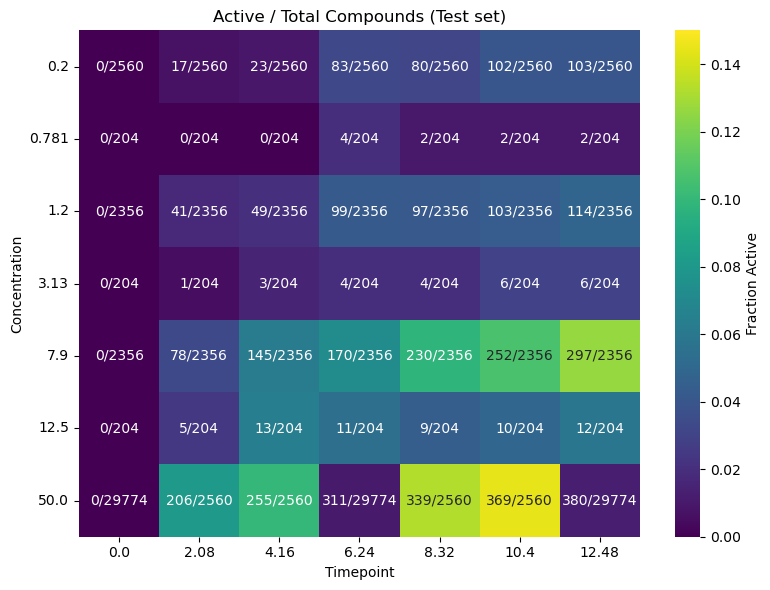

(None,)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=0.15,
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()
plot_activity_ratio_heatmap(df_train), 

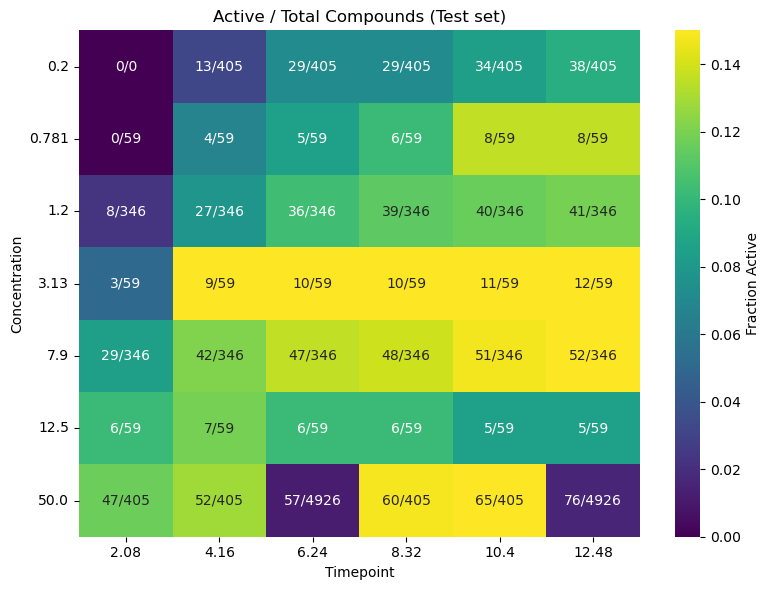

In [7]:
plot_activity_ratio_heatmap(df_val)

In [11]:

ds_val = ExplicitDataset(df_val, num_fourier=3)
val_loader = DataLoader(ds_val, batch_size=len(ds_val),collate_fn=custom_collate)
val_whole_dict=next(iter(val_loader))


save_path = f"/home/ethan2/GrowthCurve/data/test/dict_val_fourier_k_3_Celine.pkl"

# Save
with open(save_path, "wb") as f:
    pickle.dump(val_whole_dict, f)


In [12]:

for (conc,text) in ((0.2,'0_2'),(0.781,'0_781'), (1.2, '1_2'),(3.13, '3_13'), (7.9,'7_9'), (12.5,'12_50'), (50, '50')):
    val=ExplicitDataset(df_val[(df_val['Concentration'] == conc)&(df_val['Timepoint'] != 0)].reset_index(drop=True), num_fourier=3)
    val_loader = DataLoader(val, batch_size=len(val),collate_fn=custom_collate)
    val_whole_dict=next(iter(val_loader))


    save_path = f"/home/ethan2/GrowthCurve/data/test/dict_val_fourier_k_3_conc_{text}_Celine.pkl"

    # Save
    with open(save_path, "wb") as f:
        pickle.dump(val_whole_dict, f)


# Make Celine val compound list 

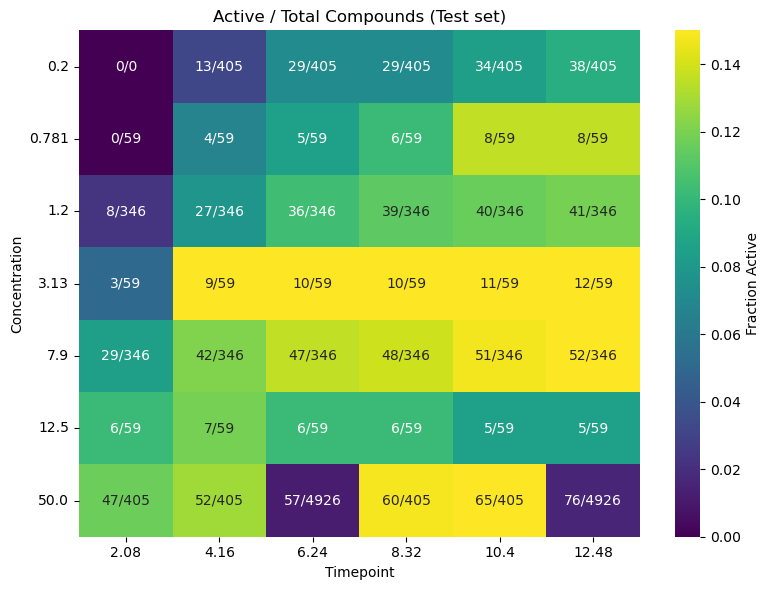

In [24]:
plot_activity_ratio_heatmap(df_val)

# Spline investigation

I need to get a feel for how RectBivariateSpline works. I need to chose a compound and and visualize the interpolation. I should:

-Investigate how many points I should use to do the inteprolation (all or is n sufficient)
-Vary the hyper-parameters of the spline and see how it works.

In [10]:
import pandas as pd
import numpy as np
from scipy.interpolate import RectBivariateSpline


In [6]:
df_train[(df_train['is_Active'] == 1) & (df_train['Timepoint']==12.48) & (df_train['Concentration']==50)]
#Lefamulin (acetate) seems like a strong antobiotic
#Salinomycin (sodium salt) maybe less so

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp,Smiles_canonical
52734,A04,546,50.0,Lefamulin (acetate),0,CC(O)=O.C[C@@H]1C23[C@](C(CC3)=O)([H])C([C@H](...,12.48,0.016784,1,O=C(CSC1CCCCC1)OC1CCCCC23CCCC1C2C(=O)CC3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...",C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CC[C@@H](N)C...
52735,A05,546,50.0,Cefodizime (sodium),0,O=C(C(N12)=C(CSC3=NC(C)=C(CC(O[Na])=O)S3)CS[C@...,12.48,0.000000,1,N=C(C(=O)NC1C(=O)N2C=C(CSc3nccs3)CSC12)c1cscn1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, ...",CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O[Na])=C(CS...
52741,A12,546,50.0,AFN-1252,0,O=C(N(C)CC1=C(C)C2=CC=CC=C2O1)/C=C/C(C=C3CC4)=...,12.48,0.066888,1,O=C1CCC2=CC(C=CC(=O)NCc3cc4ccccc4o3)=CNC2=N1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, ...",Cc1c(CN(C)C(=O)/C=C/C2=CNC3=NC(=O)CCC3=C2)oc2c...
52742,A13,546,50.0,Lipofermata,0,O=C1NC2=C(C=C(Br)C=C2)C13SC(C4=CC=CC=C4)=NN3,12.48,0.010547,1,O=C1Nc2ccccc2C12NN=C(c1ccccc1)S2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, ...",O=C1Nc2ccc(Br)cc2C12NN=C(c1ccccc1)S2
52743,A14,546,50.0,LolCDE-IN-1,0,FC1=CC=C(COC2=CC(C3=NNC=C3C4=CC=NC=C4)=CC=C2)C=C1,12.48,0.000000,1,c1ccc(COc2cccc(-c3n[nH]cc3-c3ccncc3)c2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, ...",Fc1ccc(COc2cccc(-c3n[nH]cc3-c3ccncc3)c2)cc1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175132,O21,547,50.0,Lasalocid (sodium),0,O=C(O[Na])C1=C(CC[C@@H](C)[C@H](O)[C@H](C)C([C...,12.48,0.788963,1,O=C(CCCCCc1ccccc1)CC1CCC(C2CCCCO2)O1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, ...",CC[C@@H](C(=O)[C@@H](C)[C@@H](O)[C@H](C)CCc1cc...
175365,O21,S05,50.0,UM0073730:01,0,NC(NC1=O)=NC(/C=C/c2ccccc2)=C1[N+]([O-])=O,12.48,0.782246,1,O=c1cc(C=Cc2ccccc2)nc[nH]1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...",Nc1nc(/C=C/c2ccccc2)c([N+](=O)[O-])c(=O)[nH]1
175427,B14,S06,50.0,UM0138857:01,0,CN(C)CCCNc1c(c(ccc(-c2n[nH]nn2)c2)c2[nH]2)c2nc...,12.48,0.893871,1,c1ccc(-c2ncc3c(n2)[nH]c2cc(-c4nn[nH]n4)ccc23)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...",CN(C)CCCNc1nc(-c2ccccc2)nc2[nH]c3cc(-c4nn[nH]n...
175444,N15,S06,50.0,UM0133447:01,0,OC(C(C=C(C(c1c2O)=O)O)=Cc1cc(O)c2O)=O,12.48,0.299081,1,O=c1ccccc2ccccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",O=C(O)c1cc(O)c(=O)c2c(O)c(O)c(O)cc2c1


In [11]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import RectBivariateSpline

def sample_cls_interpolation_plot_from_meta(
    metas: list,
    compound: str,
    *,
    k: int = 5,
    spline_deg: int,
    eval_grid_size: int = 100,
    rng: np.random.Generator | None = None,
    return_objects: bool = True,
):
    """
    Visualize OD interpolation + classification labels for a given compound using saved CompoundMeta objects.

    Args:
        metas (list[CompoundMeta]): Loaded list of per-compound metadata objects.
        compound (str): Compound name to visualize.
        k (int): Number of nearest neighbors for classification.
        spline_deg (int): Degree of RectBivariateSpline (default=2 → bicubic).
        eval_grid_size (int): Resolution of the surface grid.
        rng (np.random.Generator | None): Random number generator for reproducibility.
        return_objects (bool): If True, returns dict with spline, fig, etc.
    """
    if rng is None:
        rng = np.random.default_rng()

    # --- Find target compound meta ---
    meta = None
    for m in metas:
        if m.compound == compound:
            meta = m
            break
    if meta is None:
        raise ValueError(f"Compound {compound!r} not found in loaded metas.")

    piv_od = meta.pivot_od
    piv_cls = meta.pivot_cls

    t_vals = piv_od.index.values.astype(float)
    c_vals = piv_od.columns.values.astype(float)

    # --- Sample query point ---
    t_samp = rng.uniform(float(t_vals.min()), float(t_vals.max()))
    logc_min, logc_max = np.log(float(c_vals.min())), np.log(float(c_vals.max()))
    logc_samp = rng.uniform(logc_min, logc_max)
    c_samp = float(np.exp(logc_samp))

    # --- Choose nearest neighbors for spline ---
    def nearest_k(vals, target, k, logspace=False):
        if logspace:
            idx = np.argsort(np.abs(np.log(vals) - np.log(target)))[:k]
        else:
            idx = np.argsort(np.abs(vals - target))[:k]
        return np.sort(vals[idx])

    need_t = spline_deg + 1
    need_c = spline_deg + 1
    times_used = nearest_k(t_vals, t_samp, need_t, logspace=False)
    concs_used = nearest_k(c_vals, c_samp, need_c, logspace=True)

    grid_od = piv_od.loc[times_used, concs_used]
    if grid_od.isna().any().any():
        raise ValueError("Local OD rectangle has missing values; cannot fit spline.")

    X = grid_od.index.values.astype(float)
    Ylog = np.log(grid_od.columns.values.astype(float))
    Z = grid_od.to_numpy()

    spline = RectBivariateSpline(X, Ylog, Z, kx=spline_deg, ky=spline_deg, s=0.0)

    # --- Evaluate spline surface ---
    x_dense = np.linspace(X.min(), X.max(), eval_grid_size)
    ylog_dense = np.linspace(Ylog.min(), Ylog.max(), eval_grid_size)
    Xd, Yld = np.meshgrid(x_dense, ylog_dense, indexing="ij")
    Zd = spline(x_dense, ylog_dense)
    Y_conc_dense = np.exp(Yld)

    # --- Interpolated OD at sampled point ---
    z_samp = float(spline.ev(t_samp, np.log(c_samp)))

    # --- Classification neighbors (distance-weighted k-NN in 3D) ---
    grid_cls = piv_cls.loc[times_used, concs_used]
    coords_time, coords_conc = np.meshgrid(
        grid_cls.index.values.astype(float),
        grid_cls.columns.values.astype(float),
        indexing="ij"
    )
    coords_time = coords_time.ravel()
    coords_conc = coords_conc.ravel()
    coords_logc = np.log(coords_conc)

    grid_od = piv_od.loc[times_used, concs_used]
    coords_od = grid_od.to_numpy().ravel()
    coords_labels = grid_cls.to_numpy().ravel().astype(int)

    mask = ~np.isnan(coords_od) & ~np.isnan(coords_labels)
    coords_time = coords_time[mask]
    coords_logc = coords_logc[mask]
    coords_od = coords_od[mask]
    coords_labels = coords_labels[mask]

    query = np.array([t_samp, np.log(c_samp), z_samp])
    coords = np.column_stack([coords_time, coords_logc, coords_od])

    dists = np.linalg.norm(coords - query, axis=1)
    nn_idx_cls = np.argsort(dists)[:k]

    nn_labels = coords_labels[nn_idx_cls]
    nn_dists = dists[nn_idx_cls]

    eps = 1e-8
    weights = 1.0 / (nn_dists + eps)
    p_active = float(np.sum(weights * nn_labels) / np.sum(weights))
    pred_label = int(p_active >= 0.5)

    # --- Visualization ---
    fig = go.Figure()

    # Interpolated OD surface
    surf_tc = go.Surface(
        x=Xd, y=Y_conc_dense, z=Zd,
        colorscale="Viridis", opacity=0.6, showscale=False,
        name="Interpolated OD surface"
    )

    # Observed points (colored by is_Active)
    obs = go.Scatter3d(
        x=piv_od.index.values.repeat(piv_od.shape[1]),
        y=np.tile(piv_od.columns.values, len(piv_od.index)),
        z=piv_od.values.ravel(),
        mode="markers",
        marker=dict(
            size=6,
            color=piv_cls.values.ravel(),
            colorscale=[[0, "blue"], [1, "red"]],
            symbol="circle"
        ),
        name="Observed points"
    )

    # k-NN neighbors (X markers)
    obs_cls = go.Scatter3d(
        x=coords_time[nn_idx_cls], y=np.exp(coords_logc[nn_idx_cls]), z=coords_od[nn_idx_cls],
        mode="markers",
        marker=dict(size=6,
                    color=nn_labels,
                    colorscale=[[0, "blue"], [1, "red"]],
                    symbol="x"),
        name=f"k-NN neighbors (k={k})"
    )

    # Sampled query point
    samp = go.Scatter3d(
        x=[t_samp], y=[c_samp], z=[z_samp],
        mode="markers",
        marker=dict(size=5, color="black", symbol="x",
                    line=dict(width=2, color="yellow")),
        name=f"Sample (pred={pred_label}, p={p_active:.2f})",
        hovertemplate="t=%{x:.3g}<br>c=%{y:.3g}<br>OD≈%{z:.3g}"
                      f"<br>p_active={p_active:.3f}<br>pred={pred_label}<extra></extra>",
    )

    fig.add_traces([surf_tc, obs, obs_cls, samp])
    fig.update_layout(
        title=f"{compound} — OD interpolation + classification "
              f"(pred={pred_label}, p_active={p_active:.2f}, k={k})",
        scene=dict(
            xaxis_title="Timepoint",
            yaxis_title="Concentration (µM)",
            zaxis_title="OD",
            aspectmode="cube",
        ),
        margin=dict(l=0, r=0, b=0, t=60),
    )

    if return_objects:
        return {
            "spline": spline,
            "fig": fig,
            "t_samp": t_samp, "c_samp": c_samp, "z_samp": z_samp,
            "p_active": p_active,
            "pred_label": pred_label,
            "nn_idx_cls": nn_idx_cls,
        }


## Active Compounds

UM0106969:01

In [30]:
df_train[df_train['Concentration'] == 3.13]['Compound'].unique()

array(['Z1084007582', 'Z1172141090', 'Z1223049609', 'Z1252775035',
       'Z1268682983', 'Z1457064891', 'Z1546137448', 'Z1592539344',
       'Z168691812', 'Z1695676425', 'Z1708216761', 'Z194258546',
       'Z1998150879', 'Z212817766', 'Z24763818', 'Z2568438182',
       'Z27542156', 'Z295866336', 'Z295866338', 'Z295866340',
       'Z339892772', 'Z51907538', 'Z605760074', 'Z608581708', 'Z64431318',
       'Z735389982', 'Z788681184', 'Z115677882', 'Z1203873365',
       'Z1203873429', 'Z1269587289', 'Z1271007419', 'Z1337136871',
       'Z169865972', 'Z1833589281', 'Z1836232399', 'Z1916078976',
       'Z1916196357', 'Z2067235752', 'Z237862988', 'Z2437372362',
       'Z2713957313', 'Z2970754034', 'Z317626212', 'Z31769013',
       'Z320034720', 'Z339239910', 'Z363131758', 'Z425558132',
       'Z733859464', 'Z737888452', 'Z806961698', 'Z906002926',
       'Z968683018', 'Z98609880', 'Z1139533754', 'Z1230093043',
       'Z1328600108', 'Z1341311940', 'Z1491223240', 'Z1491333280',
       'Z1827464

In [31]:
import pickle

# Load your saved metadata list
with open("/home/ethan2/GrowthCurve/data/train/Celine_CompoundMetas_list.pkl", "rb") as f:
    metas = pickle.load(f)

In [ ]:
target_compound = "Z1084007582"

meta = next((m for m in metas if m.compound == target_compound), None)

In [20]:
print(meta)

None


In [112]:
from collections import Counter
import numpy as np

# Initialize counter
conc_counter = Counter()

# Loop through each CompoundMeta object
for meta in metas:
    # Add all unique concentrations for that compound
    conc_counter.update(meta.c_vals.astype(float))

# Convert to sorted dict for readability
conc_counts = dict(sorted(conc_counter.items()))

# Display results
print("📊 Frequency of unique concentration values across all compounds:")
for conc, count in conc_counts.items():
    print(f"  {conc:>6.3f} µM → {count} compounds")


📊 Frequency of unique concentration values across all compounds:
   0.200 µM → 2560 compounds
   0.781 µM → 204 compounds
   1.200 µM → 2356 compounds
   3.130 µM → 204 compounds
   7.900 µM → 2356 compounds
  12.500 µM → 204 compounds
  50.000 µM → 29774 compounds


In [165]:
eligible_metas = [
    m for m in metas
    if (not m.single_conc) and (m.is_active_at_12_50 is True)
]

In [38]:
active_12_50 = df_train[
    (df_train["Timepoint"] == 12.48) &
    (df_train["Concentration"] == 50) &
    (df_train["is_Active"] == 1)
]["Compound"].unique()

# Step 2: find compounds that also have a record at conc=3.13
has_3_13 = df_train[df_train["Concentration"] == 3.13]["Compound"].unique()

# Step 3: intersection → compounds meeting both conditions
eligible_compounds = sorted(set(active_12_50) & set(has_3_13))


In [41]:
eligible_compounds

['Z1561183584',
 'Z2439582327',
 'Z295866336',
 'Z295866338',
 'Z2967175994',
 'Z3794352988',
 'Z4283448992',
 'Z5001810369',
 'Z5397885587',
 'Z56950524',
 'Z5876101828',
 'Z7956608122',
 'Z85911415']

In [47]:
import numpy as np

# Initialize RNG (optional seed for reproducibility)
rng = np.random.default_rng()

# Filter: only compounds that are multi-concentration AND active at 12h, 50 µM
eligible_metas = [
    m for m in metas
    if (not m.single_conc) and (m.is_active_at_12_50 is True)
]

if not eligible_metas:
    raise ValueError("No eligible compounds with multi-concentration and is_active_at_12_50=True found.")

# Randomly select one eligible compound
meta_choice = rng.choice(eligible_metas)
compound_name = meta_choice.compound

print(f"🎲 Randomly selected compound: {compound_name} (multi-conc, active at 12h 50µM)")

# Visualize interpolation
out = sample_cls_interpolation_plot_from_meta(
    metas=metas,
    compound='Z2439582327',
    k=4,
    spline_deg=1,
    eval_grid_size=100,
    rng=rng,  # ensures reproducible t_samp / c_samp
)

out["fig"].show()


🎲 Randomly selected compound: Anhydrotetracycline (hydrochloride) (multi-conc, active at 12h 50µM)


UM0054239:01 has a mistake at timepoint 6h and conc 7.9
Cefixime is very weird looking
Eltrombopag is wrong at timepoint 10.4
Should I oversample things that are active or have multiple concnetrations?

In [9]:
out = sample_cls_interpolation_plot(df_train, "Nosiheptide",k=4, spline_deg=2, eval_grid_size=100, log_base=10.0)
print("OD at sampled point (interpolated):")
out["fig"].show()

#Lefamulin (acetate)

OD at sampled point (interpolated):


# Interpolation 1 conc

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_single_conc_quadratic(df: pd.DataFrame, compound: str,
                               conc_target: float = 50.0,
                               times_expected=(0.0, 6.24, 12.48),
                               tol: float = 1e-6, num_points: int = 200,
                               clamp_to_max_endpoints: bool = True):
    """
    Fit y(t) = a t^2 + b t + c at conc==conc_target using exactly three expected timepoints,
    then plot the quadratic and the observed points. If clamp_to_max_endpoints is True,
    the plotted curve is clamped so its maximum never exceeds max(OD at the later two endpoints).
    Assumes OD at time ~0 is (effectively) 0.

    Returns
    -------
    coeffs : np.ndarray shape (3,)  # [a, b, c]
    fig, ax : matplotlib figure and axis
    """
    # Filter & pivot
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows for compound {compound!r}.")
    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
             .sort_index(axis=0).sort_index(axis=1))

    # Find the exact/nearest column to conc_target
    cols = piv.columns.to_numpy(dtype=float)
    j = int(np.argmin(np.abs(cols - conc_target)))
    if abs(cols[j] - conc_target) > tol:
        raise ValueError(f"Expected concentration {conc_target}, got nearest {cols[j]}.")
    conc_col = cols[j]

    # Collect OD at the three required timepoints (with tolerance)
    idx_vals = piv.index.to_numpy(dtype=float)
    t_used, y_used = [], []
    for t_exp in times_expected:
        i = int(np.argmin(np.abs(idx_vals - t_exp)))
        if abs(idx_vals[i] - t_exp) > tol:
            raise ValueError(f"Missing required timepoint {t_exp} (nearest is {idx_vals[i]}).")
        t_used.append(idx_vals[i])
        y_used.append(piv.loc[idx_vals[i], conc_col])

    t_used = np.asarray(t_used, dtype=float)
    y_used = np.asarray(y_used, dtype=float)
    if np.isnan(y_used).any():
        raise ValueError("NaN encountered in required OD values.")

    # Fit quadratic y = a t^2 + b t + c (exact interpolation for 3 points)
    coeffs = np.polyfit(t_used, y_used, deg=2)

    # Evaluate on a dense grid across the observed span
    t_min, t_max = float(min(t_used)), float(max(t_used))
    t_dense = np.linspace(t_min, t_max, num_points)
    y_dense = np.polyval(coeffs, t_dense)

    # ----- SAFEGUARD: clamp the curve to max OD among the two later endpoints -----
    if clamp_to_max_endpoints:
        # Identify which of the provided expected times are the "later endpoints"
        # i.e., exclude the near-zero timepoint using tolerance
        later_mask = np.abs(np.asarray(times_expected, dtype=float)) > tol
        if later_mask.sum() != 2:
            # Fallback: use the two largest times in t_used
            order = np.argsort(t_used)
            later_mask = np.zeros_like(t_used, dtype=bool)
            later_mask[order[-2:]] = True

        cap = float(np.nanmax(y_used[later_mask]))
        y_dense = np.minimum(y_dense, cap)

    # Plot
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(t_dense, y_dense, label="Quadratic fit (clamped)" if clamp_to_max_endpoints else "Quadratic fit", linewidth=2)
    ax.scatter(t_used, y_used, s=60, zorder=3, label=f"Observed @ {conc_target:g}")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("OD")
    a, b, c = coeffs
    title = f"{compound} (conc={conc_target:g}): y = {a:.3g} t² + {b:.3g} t + {c:.3g}"
    if clamp_to_max_endpoints:
        title += "  [clamped to max(endpoints)]"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return coeffs, fig, ax



def plot_single_conc_quadratic_old(df: pd.DataFrame, compound: str,
                               conc_target: float = 50.0,
                               times_expected=(0.0, 6.24, 12.48),
                               tol: float = 1e-6, num_points: int = 200):
    """
    Fit y(t) = a t^2 + b t + c at conc==50 using exactly the three expected timepoints,
    then plot the quadratic and the observed points.

    Parameters
    ----------
    df : DataFrame with columns ['Compound','Timepoint','Concentration','OD']
    compound : str
    conc_target : float
        Expected single concentration (defaults to 50.0).
    times_expected : tuple
        The three timepoints to use for the quadratic fit.
    tol : float
        Tolerance for matching float labels in the pivot.
    num_points : int
        Number of t-values for the smooth curve.

    Returns
    -------
    coeffs : np.ndarray shape (3,)  # [a, b, c]
    fig, ax : matplotlib figure and axis
    """
    # Filter & pivot
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows for compound {compound!r}.")
    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
             .sort_index(axis=0).sort_index(axis=1))

    # Find the exact/nearest column to conc_target
    cols = piv.columns.to_numpy(dtype=float)
    j = int(np.argmin(np.abs(cols - conc_target)))
    if abs(cols[j] - conc_target) > tol:
        raise ValueError(f"Expected concentration {conc_target}, got nearest {cols[j]}.")
    conc_col = cols[j]

    # Collect OD at the three required timepoints (with tolerance)
    idx_vals = piv.index.to_numpy(dtype=float)
    t_used, y_used = [], []
    for t_exp in times_expected:
        i = int(np.argmin(np.abs(idx_vals - t_exp)))
        if abs(idx_vals[i] - t_exp) > tol:
            raise ValueError(f"Missing required timepoint {t_exp} (nearest is {idx_vals[i]}).")
        t_used.append(idx_vals[i])
        y_used.append(piv.loc[idx_vals[i], conc_col])

    t_used = np.asarray(t_used, dtype=float)
    y_used = np.asarray(y_used, dtype=float)
    if np.isnan(y_used).any():
        raise ValueError("NaN encountered in required OD values.")

    # Fit quadratic y = a t^2 + b t + c
    coeffs = np.polyfit(t_used, y_used, deg=2)

    # Evaluate on a dense grid across the observed span
    t_min, t_max = float(min(t_used)), float(max(t_used))
    t_dense = np.linspace(t_min, t_max, num_points)
    y_dense = np.polyval(coeffs, t_dense)

    # Plot
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(t_dense, y_dense, label="Quadratic fit", linewidth=2)
    ax.scatter(t_used, y_used, s=60, zorder=3, label="Observed @ 50")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("OD")
    a, b, c = coeffs
    ax.set_title(f"{compound} (conc=50): y = {a:.3g} t² + {b:.3g} t + {c:.3g}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return coeffs, fig, ax


In [12]:
# Group by compound and collect all unique concentrations per compound
concs_by_comp = df_train.groupby("Compound")["Concentration"].unique()

# Identify compounds that have exactly one unique concentration, and it's 50
only_50_compounds = concs_by_comp[concs_by_comp.apply(lambda x: len(x) == 1 and x[0] == 50)].index

# Filter the original dataframe to those compounds
df_only_50 = df_train[df_train["Compound"].isin(only_50_compounds)]

df_only_50[df_only_50['is_Active'] == 1]['Compound'].unique()


array(['Z1203873223', 'Z647396922', 'Z1646492194', 'Z1693527467',
       'Z1167728859', 'Z383079852', 'Z1376472169', 'Z226457910',
       'Z510189700', 'Z1439137756', 'Z1590661456', 'Z225101880',
       'Z2233914403', 'Z383152172', 'Z2088388996', 'Z2313243976',
       'Z396500958', 'Z1228838652', 'Z3759792316', 'Z1349163419',
       'Z1542314476', 'Z1470694932', 'Z1267882227', 'Z4215637372'],
      dtype=object)

## Actives

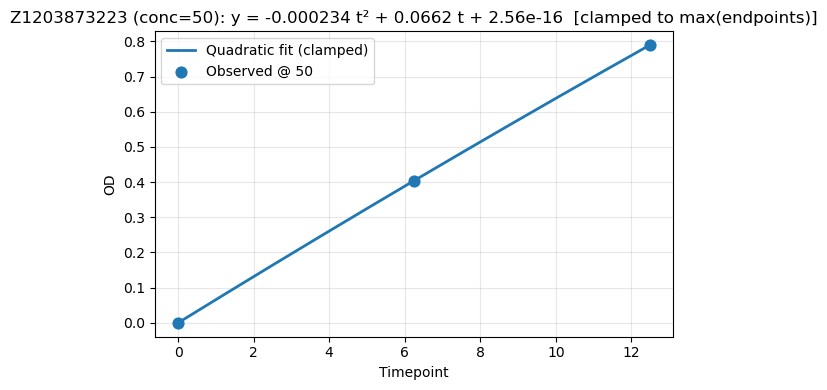

Quadratic coefficients [a, b, c]: [-2.34446874e-04  6.61502911e-02  2.56395025e-16]


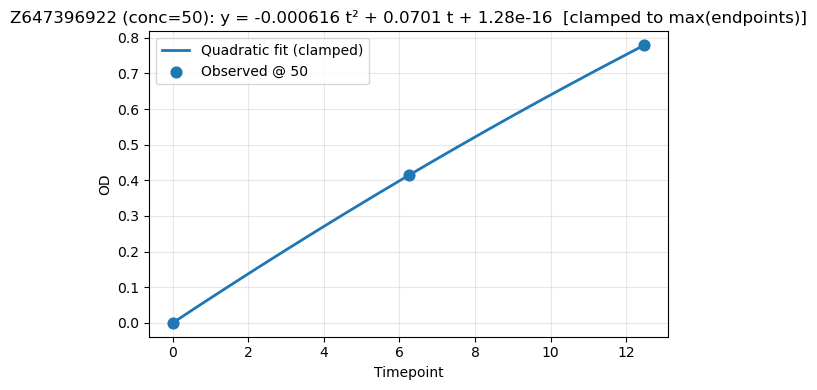

Quadratic coefficients [a, b, c]: [-6.16438220e-04  7.01282192e-02  1.28197512e-16]


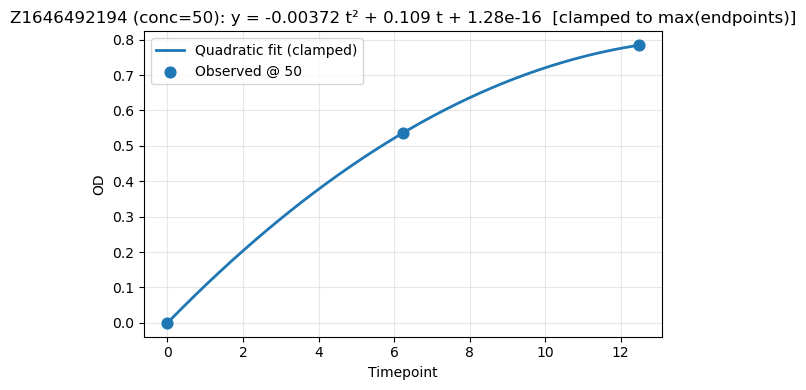

Quadratic coefficients [a, b, c]: [-3.71672202e-03  1.09217844e-01  1.28197512e-16]


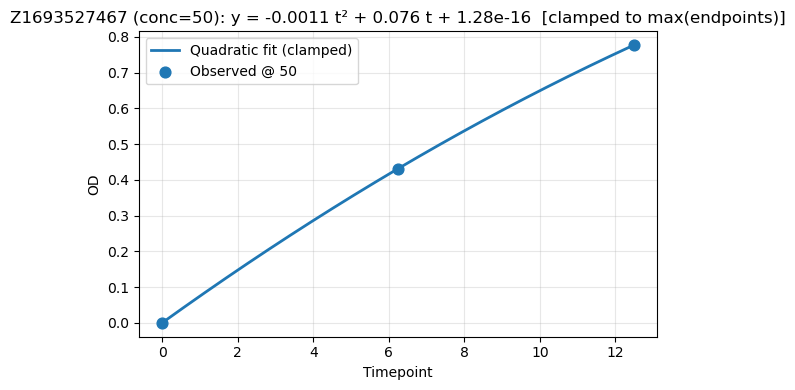

Quadratic coefficients [a, b, c]: [-1.09780451e-03  7.59553526e-02  1.28197512e-16]


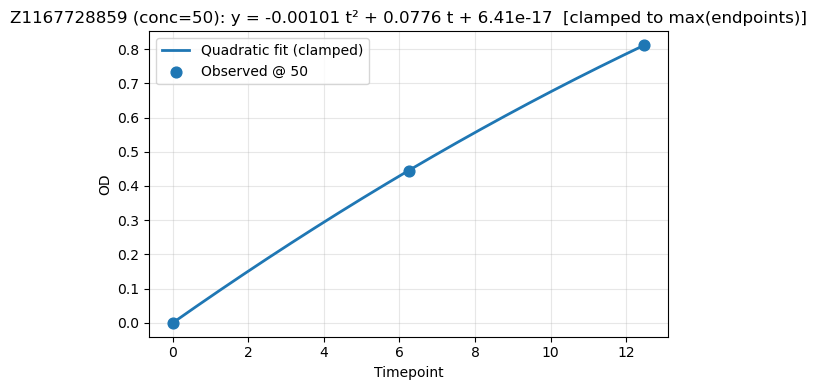

Quadratic coefficients [a, b, c]: [-1.00688641e-03  7.75892355e-02  6.40987562e-17]


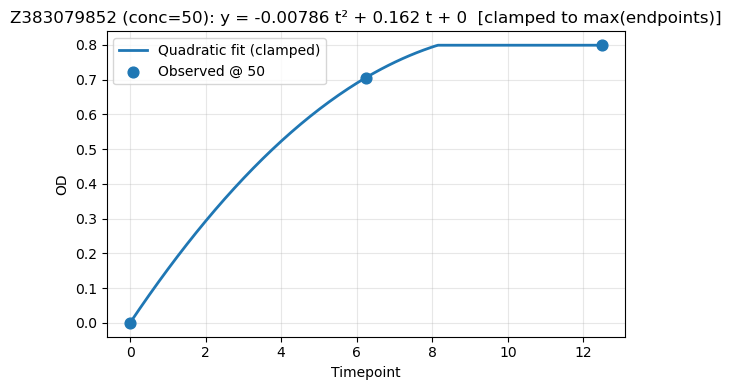

Quadratic coefficients [a, b, c]: [-0.00785938  0.16210063  0.        ]


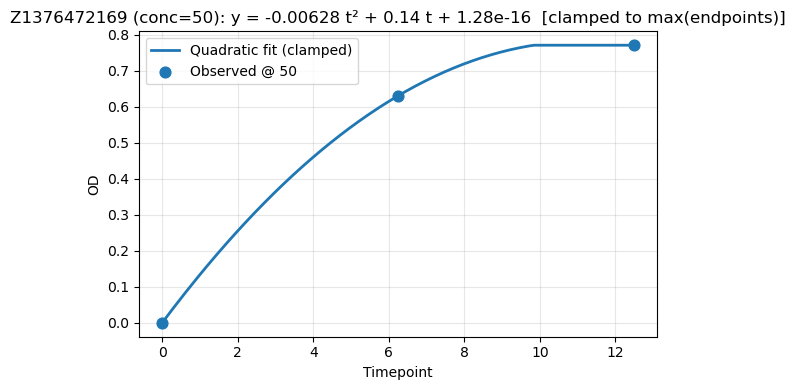

Quadratic coefficients [a, b, c]: [-6.28171225e-03  1.40154557e-01  1.28197512e-16]


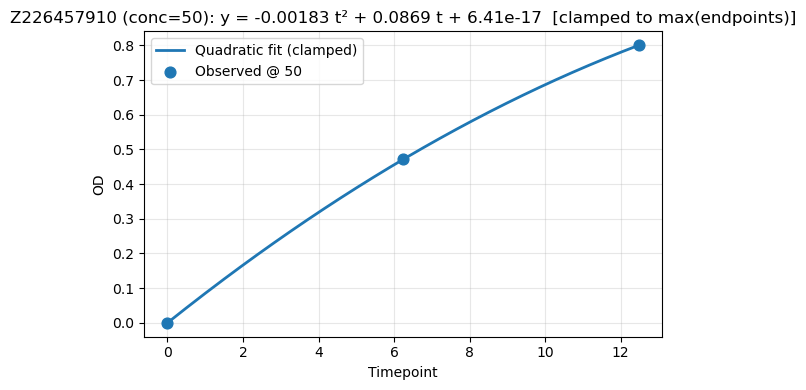

Quadratic coefficients [a, b, c]: [-1.82564706e-03  8.69128627e-02  6.40987562e-17]


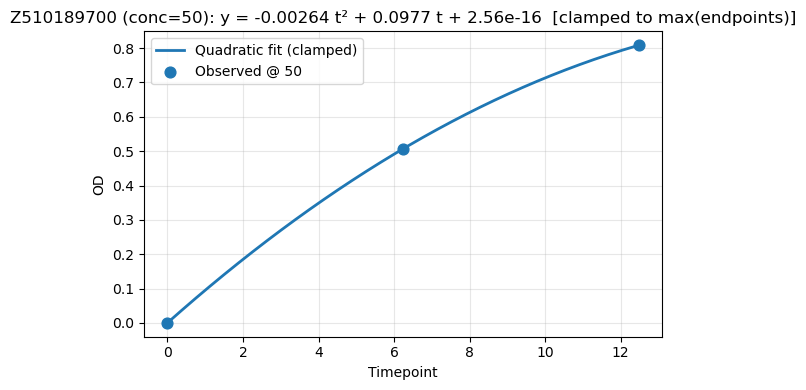

Quadratic coefficients [a, b, c]: [-2.63836082e-03  9.77171887e-02  2.56395025e-16]


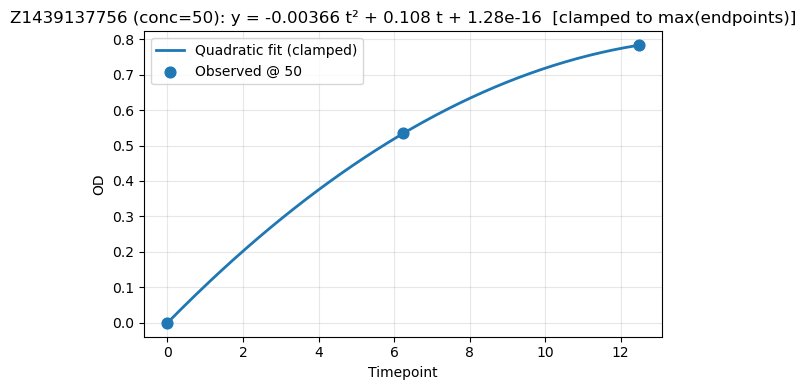

Quadratic coefficients [a, b, c]: [-3.66317638e-03  1.08445113e-01  1.28197512e-16]


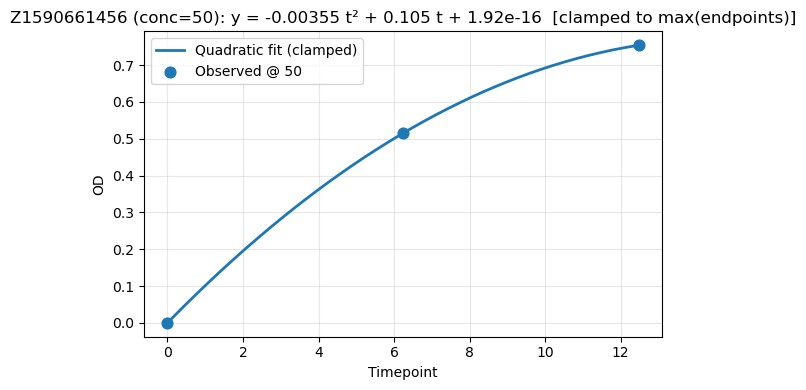

Quadratic coefficients [a, b, c]: [-3.55139409e-03  1.04734159e-01  1.92296269e-16]


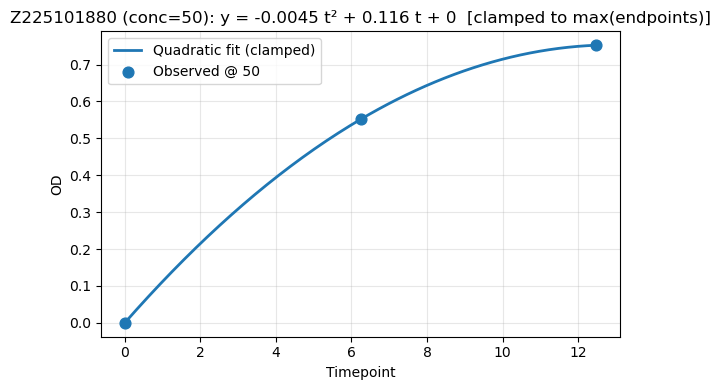

Quadratic coefficients [a, b, c]: [-0.00449914  0.11644768  0.        ]


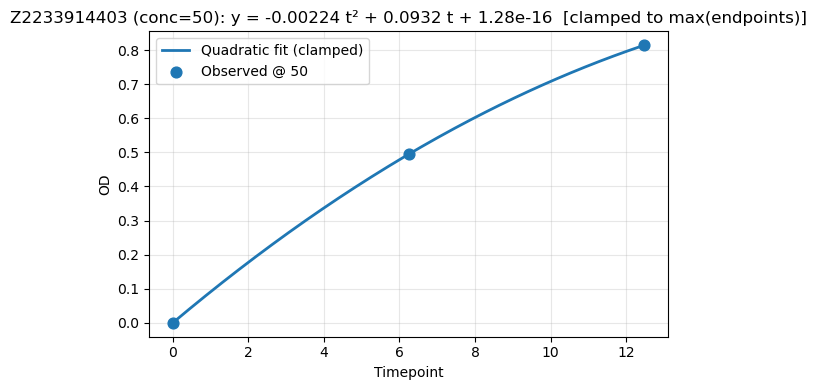

Quadratic coefficients [a, b, c]: [-2.23739214e-03  9.31753010e-02  1.28197512e-16]


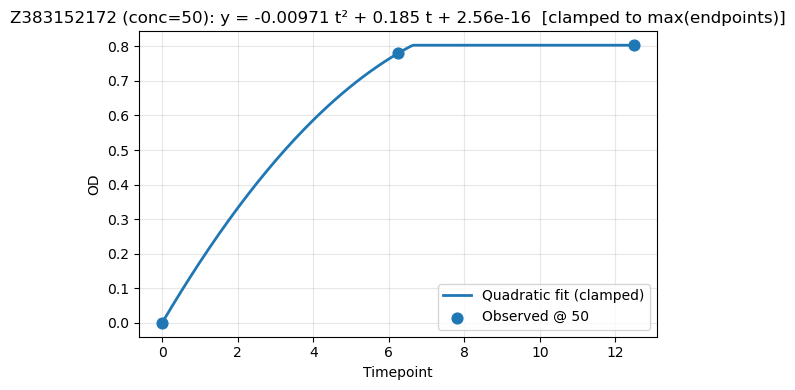

Quadratic coefficients [a, b, c]: [-9.70573638e-03  1.85497067e-01  2.56395025e-16]


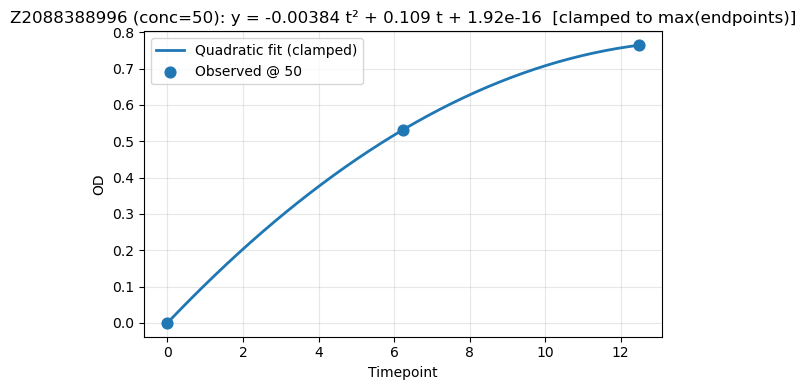

Quadratic coefficients [a, b, c]: [-3.84358881e-03  1.09207472e-01  1.92296269e-16]


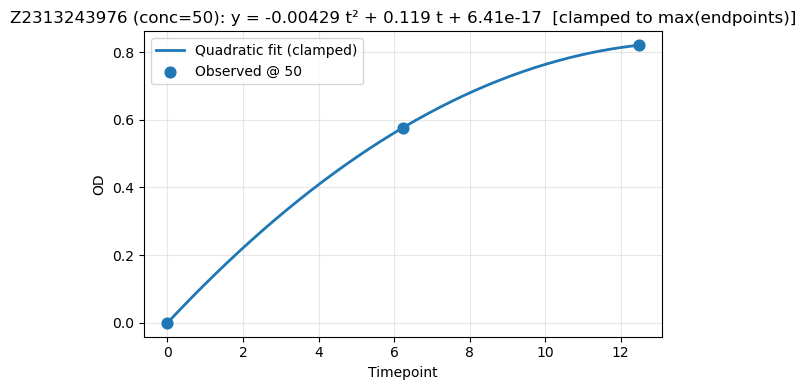

Quadratic coefficients [a, b, c]: [-4.28758706e-03  1.19234942e-01  6.40987562e-17]


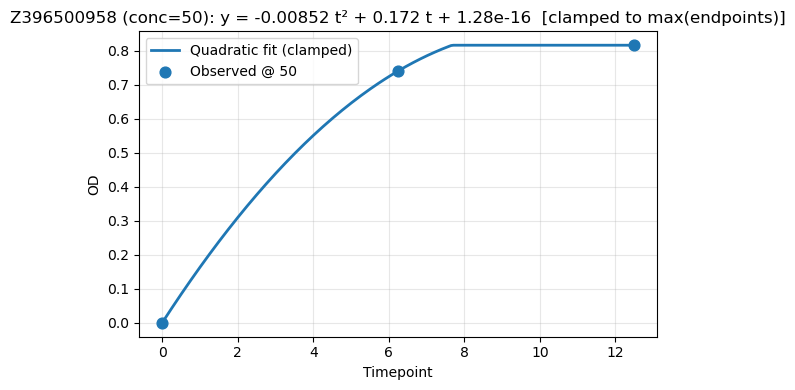

Quadratic coefficients [a, b, c]: [-8.51814575e-03  1.71658884e-01  1.28197512e-16]


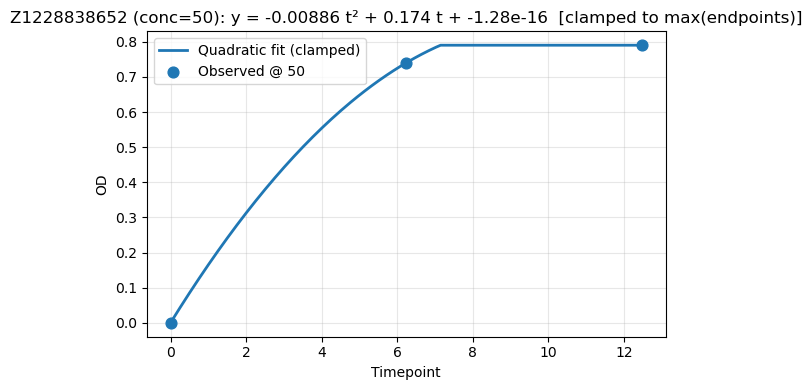

Quadratic coefficients [a, b, c]: [-8.86346063e-03  1.73945006e-01 -1.28197512e-16]


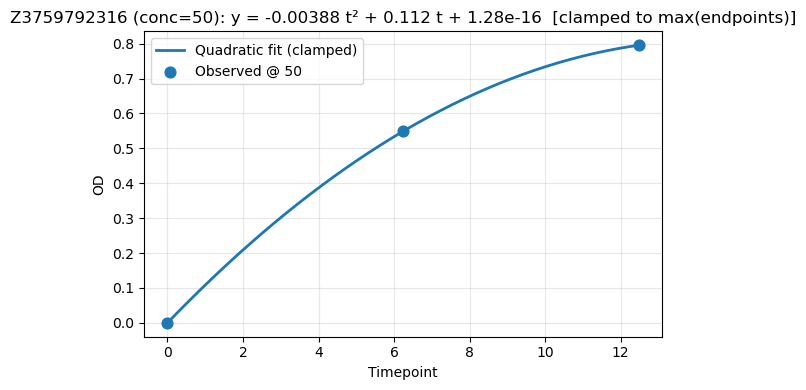

Quadratic coefficients [a, b, c]: [-3.88484674e-03  1.12234565e-01  1.28197512e-16]


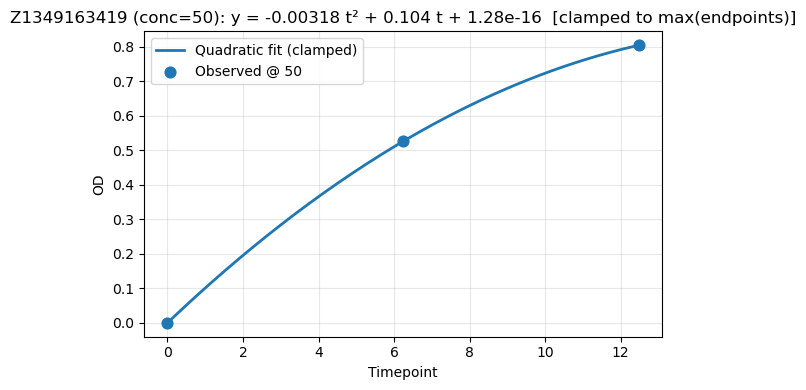

Quadratic coefficients [a, b, c]: [-3.18225489e-03  1.04231764e-01  1.28197512e-16]


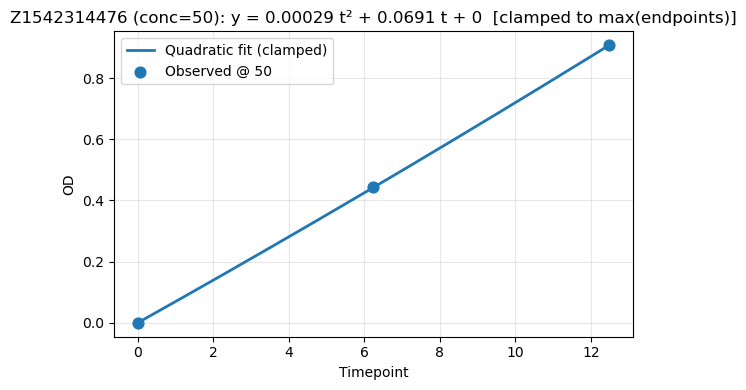

Quadratic coefficients [a, b, c]: [0.00028979 0.06908796 0.        ]


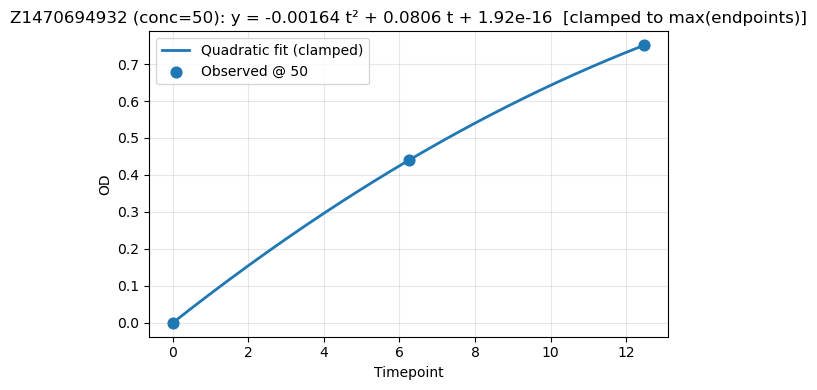

Quadratic coefficients [a, b, c]: [-1.63904184e-03  8.06292809e-02  1.92296269e-16]


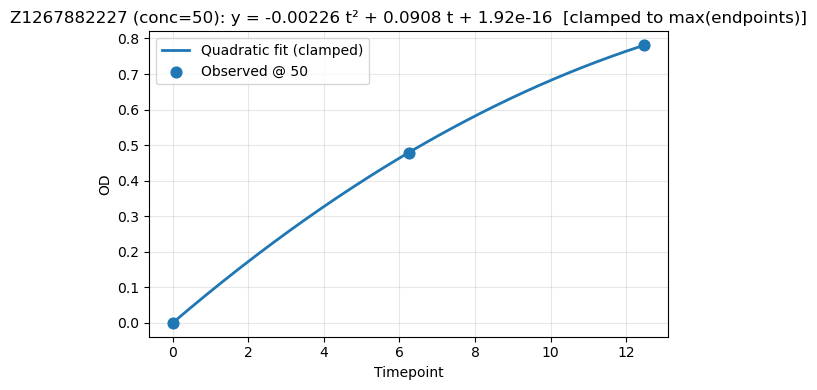

Quadratic coefficients [a, b, c]: [-2.26284259e-03  9.08198380e-02  1.92296269e-16]


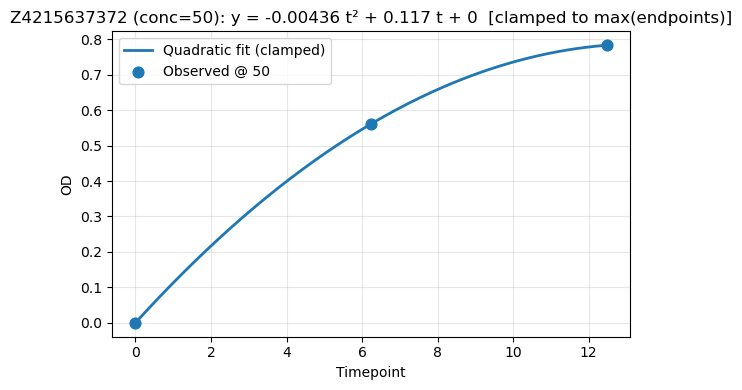

Quadratic coefficients [a, b, c]: [-0.00435756  0.1171174   0.        ]


In [16]:
for active in df_only_50[df_only_50['is_Active'] == 1]['Compound'].unique():


    coeffs, fig, ax = plot_single_conc_quadratic(df_train,active)
    print("Quadratic coefficients [a, b, c]:", coeffs)

## Inactives

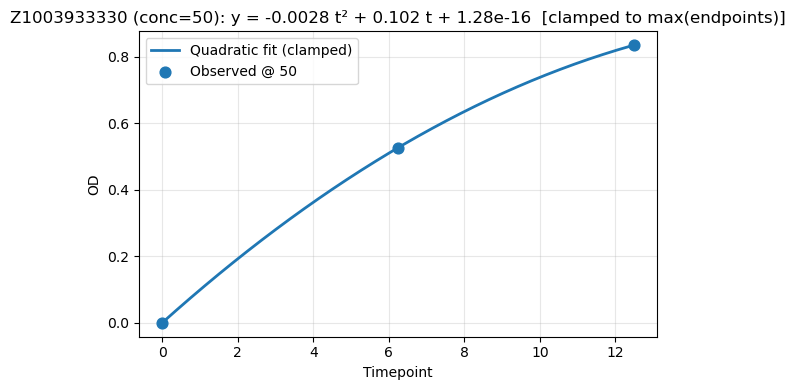

Quadratic coefficients [a, b, c]: [-2.79547228e-03  1.01774336e-01  1.28197512e-16]


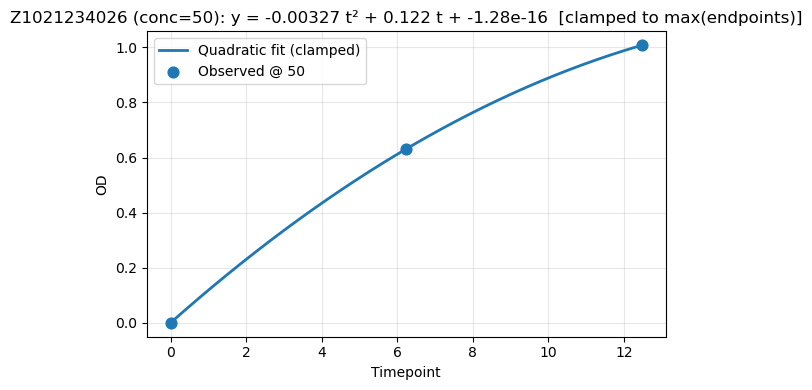

Quadratic coefficients [a, b, c]: [-3.27254028e-03  1.21569698e-01 -1.28197512e-16]


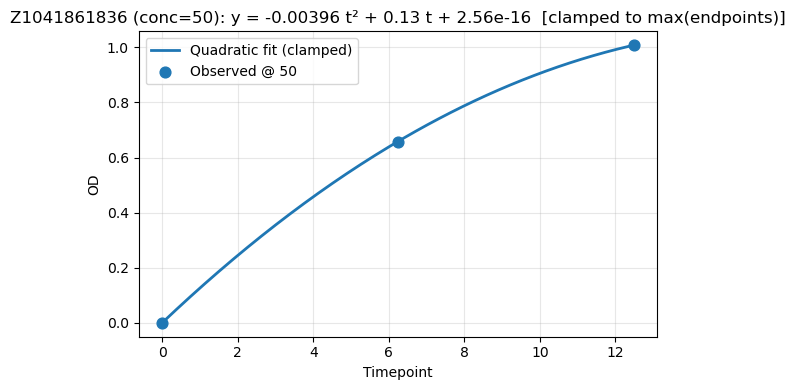

Quadratic coefficients [a, b, c]: [-3.96333700e-03  1.30213079e-01  2.56395025e-16]


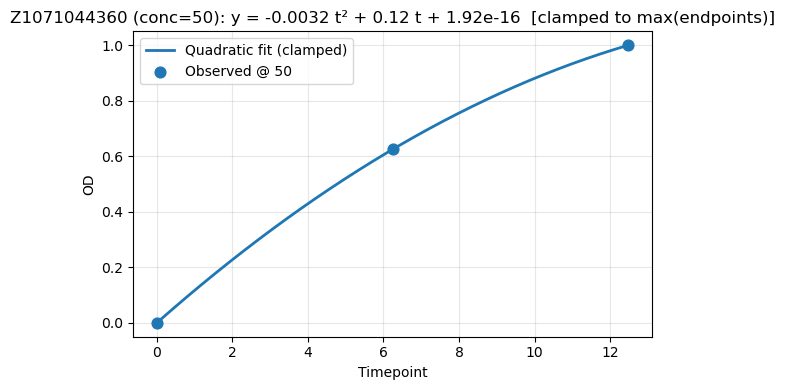

Quadratic coefficients [a, b, c]: [-3.20177910e-03  1.20059586e-01  1.92296269e-16]


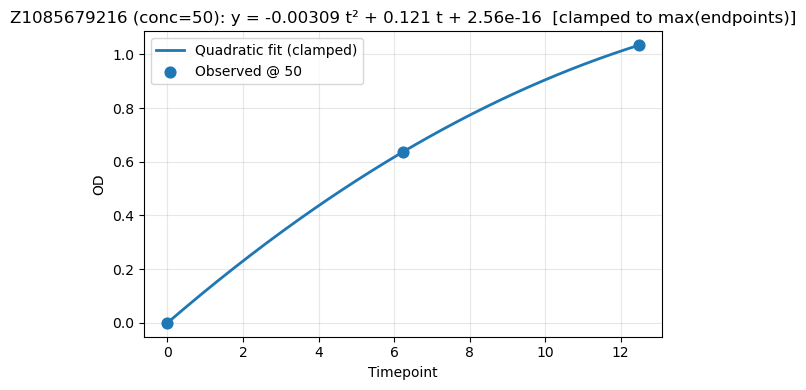

Quadratic coefficients [a, b, c]: [-3.08737467e-03  1.21377168e-01  2.56395025e-16]


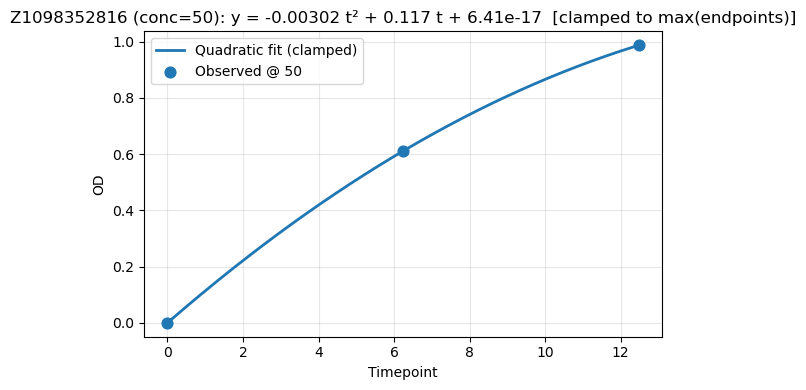

Quadratic coefficients [a, b, c]: [-3.01888360e-03  1.16780503e-01  6.40987562e-17]


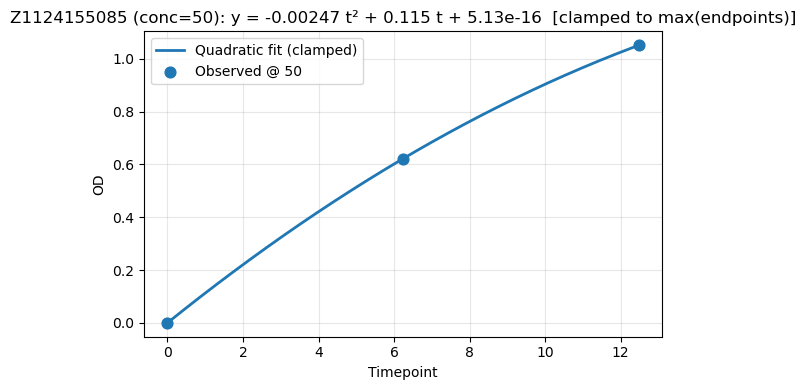

Quadratic coefficients [a, b, c]: [-2.47483416e-03  1.15129102e-01  5.12790050e-16]


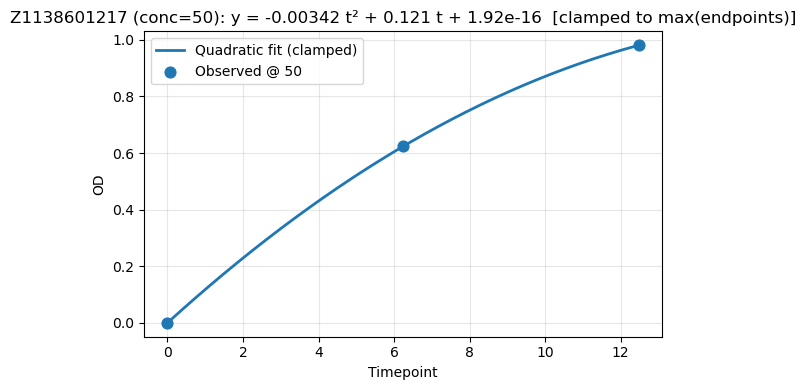

Quadratic coefficients [a, b, c]: [-3.42225227e-03  1.21331171e-01  1.92296269e-16]


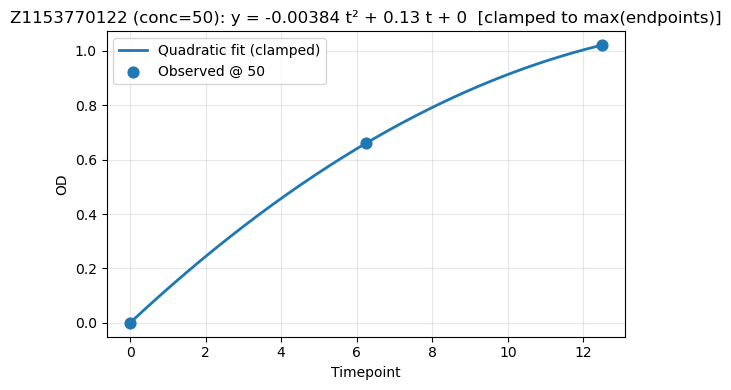

Quadratic coefficients [a, b, c]: [-0.00384097  0.12969932  0.        ]


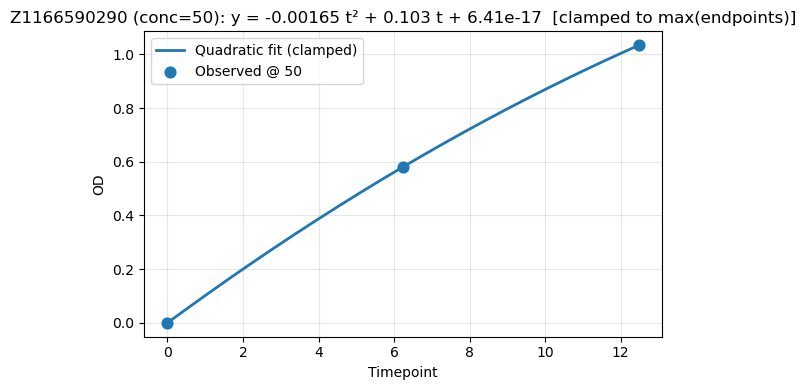

Quadratic coefficients [a, b, c]: [-1.64766467e-03  1.03441754e-01  6.40987562e-17]


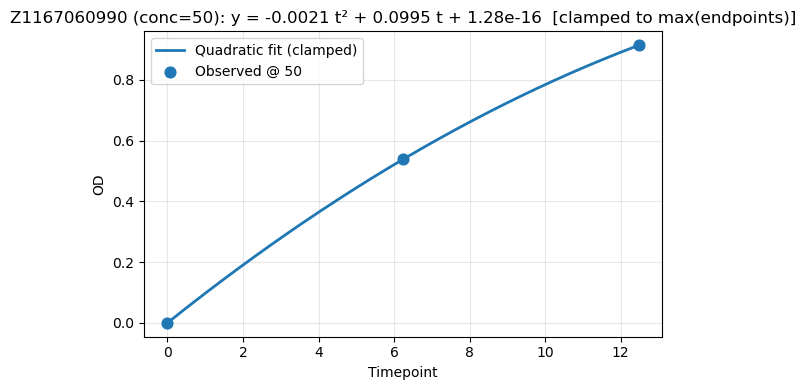

Quadratic coefficients [a, b, c]: [-2.09746915e-03  9.94595495e-02  1.28197512e-16]


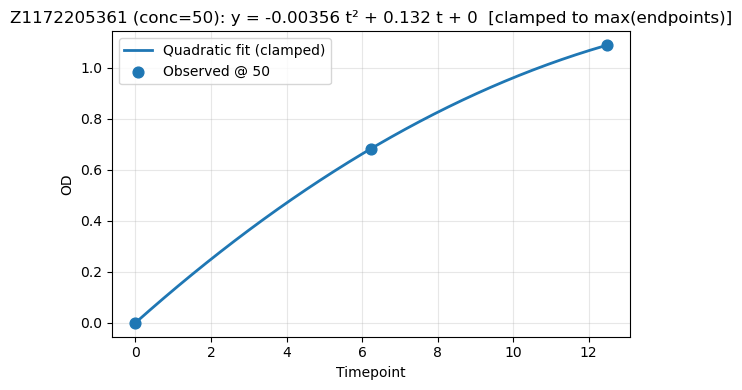

Quadratic coefficients [a, b, c]: [-0.00356436  0.13161376  0.        ]


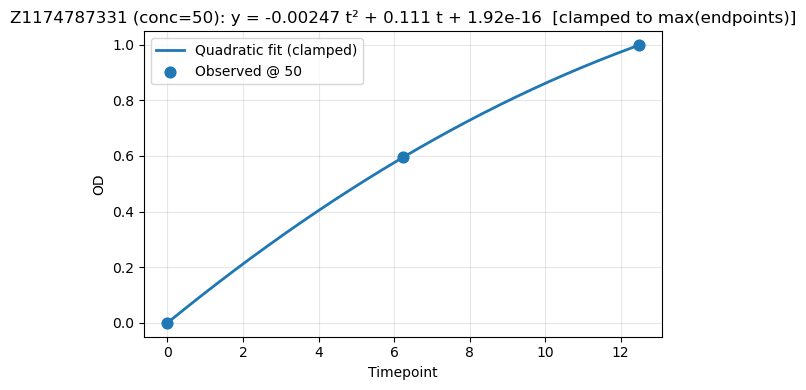

Quadratic coefficients [a, b, c]: [-2.47210508e-03  1.10804841e-01  1.92296269e-16]


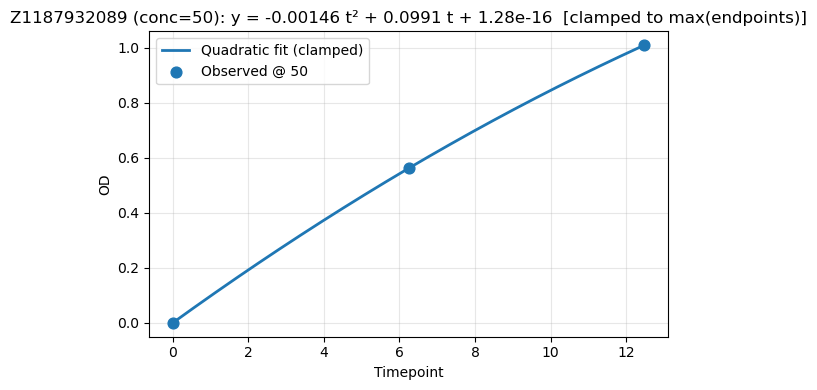

Quadratic coefficients [a, b, c]: [-1.46139774e-03  9.91200507e-02  1.28197512e-16]


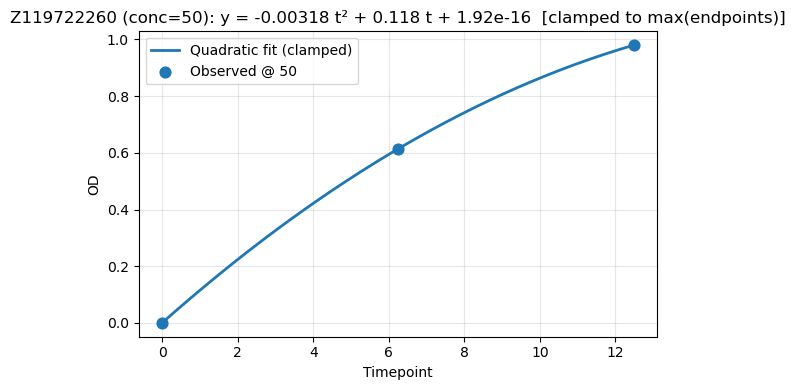

Quadratic coefficients [a, b, c]: [-3.17550850e-03  1.18139713e-01  1.92296269e-16]


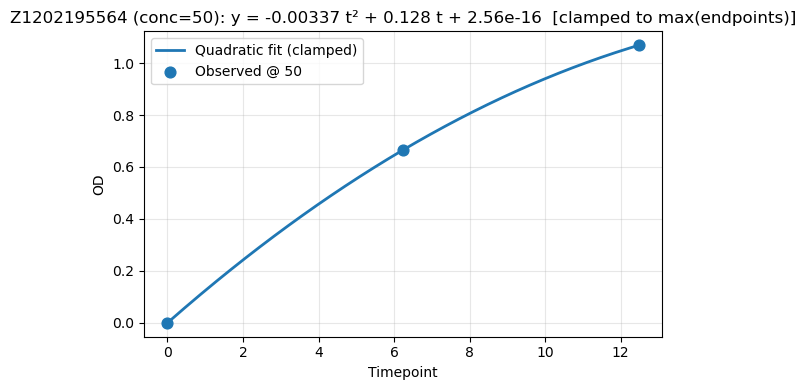

Quadratic coefficients [a, b, c]: [-3.37497487e-03  1.27745887e-01  2.56395025e-16]


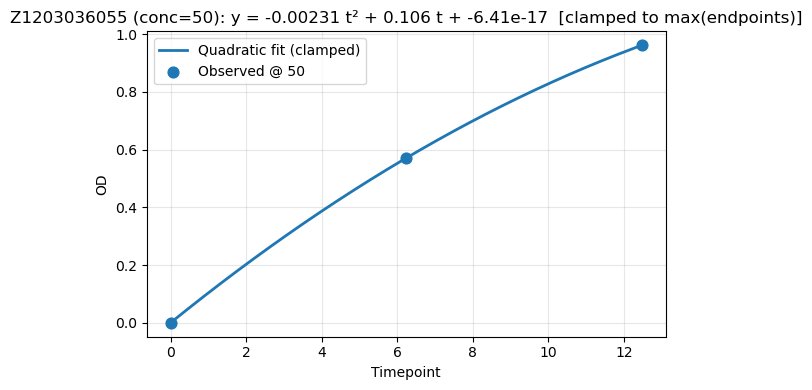

Quadratic coefficients [a, b, c]: [-2.31300948e-03  1.05909356e-01 -6.40987562e-17]


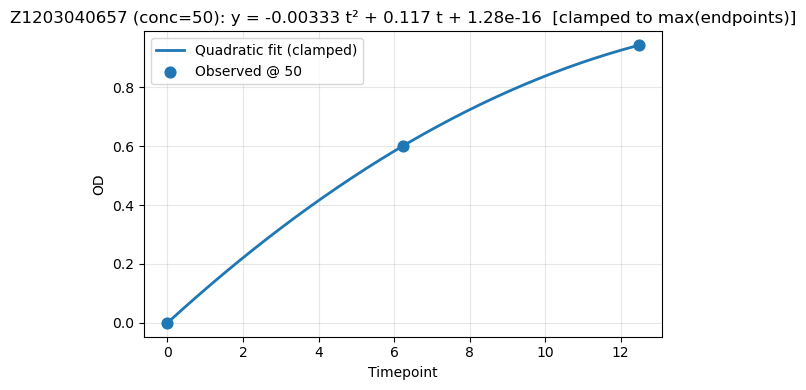

Quadratic coefficients [a, b, c]: [-3.33436052e-03  1.17139693e-01  1.28197512e-16]


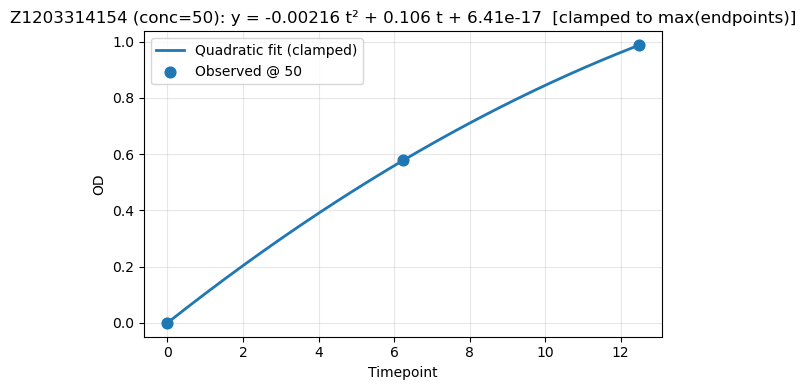

Quadratic coefficients [a, b, c]: [-2.15990588e-03  1.06028715e-01  6.40987562e-17]


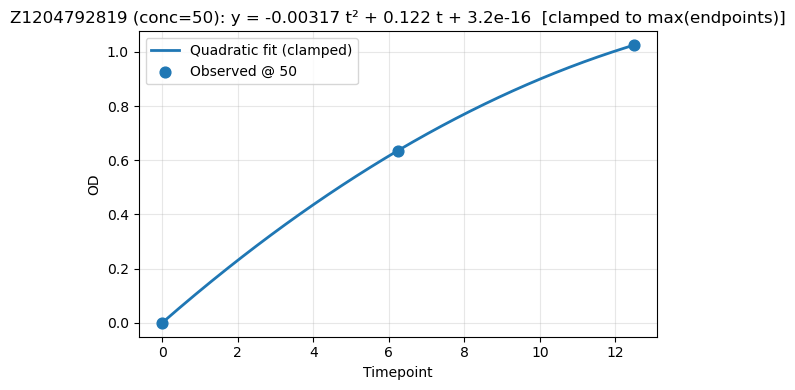

Quadratic coefficients [a, b, c]: [-3.16849983e-03  1.21662746e-01  3.20493781e-16]


In [17]:
i=0
for inactive in df_only_50[df_only_50['is_Active'] == 0]['Compound'].unique():
    if i ==20:
        break

    coeffs, fig, ax = plot_single_conc_quadratic(df_train,inactive)
    print("Quadratic coefficients [a, b, c]:", coeffs)
    i=i+1

# Insecting early timepoints

Simulating Epochs: 100%|██████████| 5/5 [02:02<00:00, 24.60s/it]


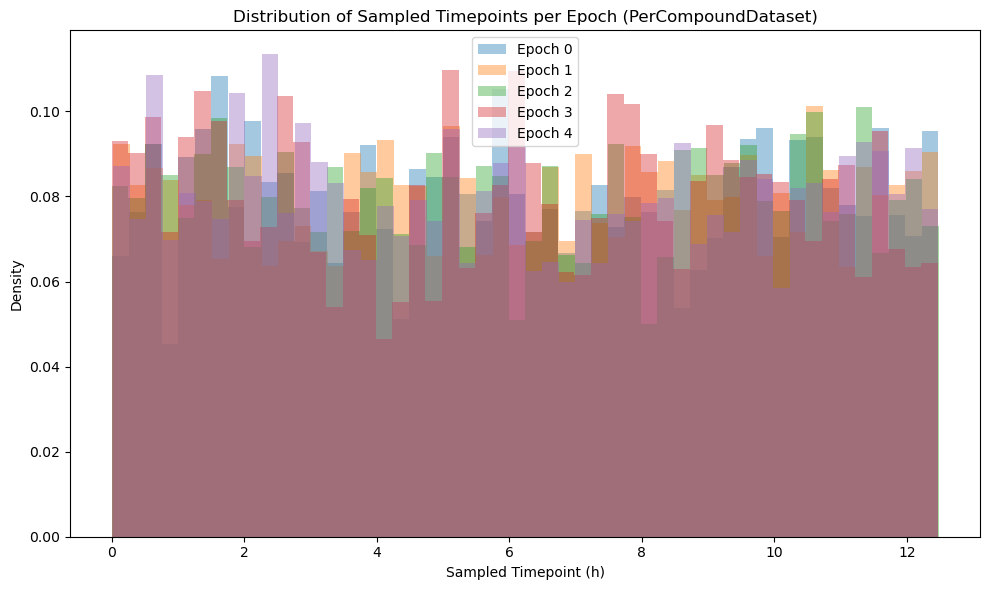

In [62]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from data_class import PerCompoundDataset, custom_collate
from tqdm import trange

# --- Config (match your sweep settings) ---
config = {
    "seed": 42,
    "samples": 5,
    "active_fraction": 0.5,
    "batch_size": 32,
}
num_epochs = 5

# --- Parallelism settings ---
num_workers = os.cpu_count()   # use all available CPU cores
persistent_workers = True
pin_memory = True
prefetch_factor = 8

# --- Initialize container for all timepoints ---
epoch_timepoints = []

for epoch in trange(num_epochs, desc="Simulating Epochs"):
    # ✅ exactly matches your training loop
    ds = PerCompoundDataset(
        df_train,
        k=config["samples"],
        seed=config["seed"] + epoch,
        num_fourier=3
    )

    # --- Weighted sampling across compounds ---
    num_actives = sum(meta.is_active_at_12_50 for meta in ds._metas)
    num_inactives = len(ds._metas) - num_actives   # fix: use ds._metas not len(ds)
    weights = torch.tensor([
        (config["active_fraction"] / num_actives if meta.is_active_at_12_50
         else (1.0 - config["active_fraction"]) / num_inactives)
        for meta in ds._metas
    ])

    g = torch.Generator().manual_seed(config["seed"] + epoch)
    sampler = WeightedRandomSampler(
        weights, num_samples=len(ds._metas), replacement=True, generator=g
    )

    # --- DataLoader setup ---
    loader = DataLoader(
        ds,
        batch_size=config["batch_size"],
        sampler=sampler,
        collate_fn=custom_collate,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )

    # --- Collect timepoints seen in this epoch ---
    t_epoch = []
    for batch in loader:
        t_raw = batch["t_raw"].cpu().numpy().ravel()
        t_epoch.extend(t_raw)

    epoch_timepoints.append(np.array(t_epoch))

# --- Plot per-epoch distributions ---
plt.figure(figsize=(10,6))
for i, t_arr in enumerate(epoch_timepoints):
    plt.hist(t_arr, bins=50, density=True, alpha=0.4, label=f"Epoch {i}")
plt.xlabel("Sampled Timepoint (h)")
plt.ylabel("Density")
plt.title("Distribution of Sampled Timepoints per Epoch (PerCompoundDataset)")
plt.legend()
plt.tight_layout()
plt.show()
